Carreguem les dades

In [1]:
import pandas as pd

# Carreguem el CSV preparat
df = pd.read_csv("../data/df_preparat.csv")



4.3 Comprovació de l'ordre de les categories i perquè surten les dades amb aquesta forma

C:\Users\david\AppData\Local\Temp\ipykernel_9288\1134879422.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  customer_cat = customer_cat.applymap(lambda x: 1 if x > 0 else 0)


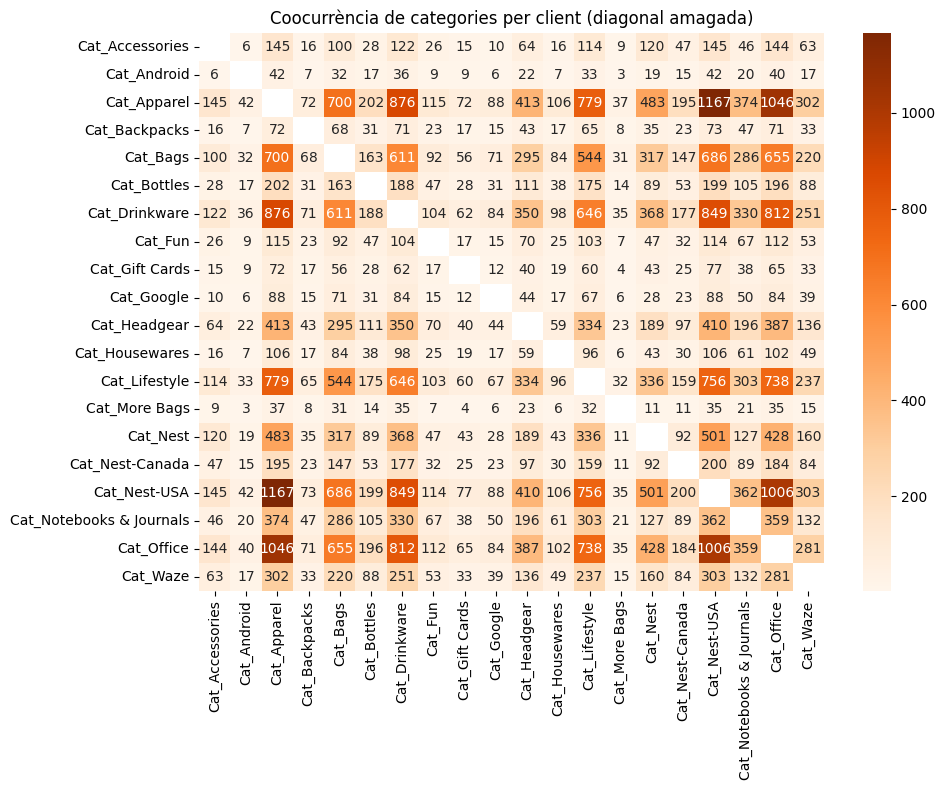

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Seleccionem categories
category_cols = [col for col in df.columns if col.startswith('Cat_')]

df_cat_cust = df[['CustomerID'] + category_cols]

# 2. Matriu binària per client i categoria
customer_cat = df_cat_cust.groupby('CustomerID')[category_cols].sum()
customer_cat = customer_cat.applymap(lambda x: 1 if x > 0 else 0)

# 3. Matriu de coocurrència
category_co_matrix_cust = customer_cat.T.dot(customer_cat)

# 4. Eliminem files/columnes buides si n'hi ha
category_co_matrix_cust = category_co_matrix_cust.loc[
    (category_co_matrix_cust.sum(axis=1) > 0),
    (category_co_matrix_cust.sum(axis=0) > 0)
]

# 5. Convertim NaNs a 0 per seguretat
category_co_matrix_cust = category_co_matrix_cust.fillna(0)

# 6. Eliminem visualment la diagonal
co_matrix_visual = category_co_matrix_cust.astype(float).copy()
np.fill_diagonal(co_matrix_visual.values, np.nan)

# 7. Visualització
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_visual, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrència de categories per client (diagonal amagada)")
plt.tight_layout()
plt.show()


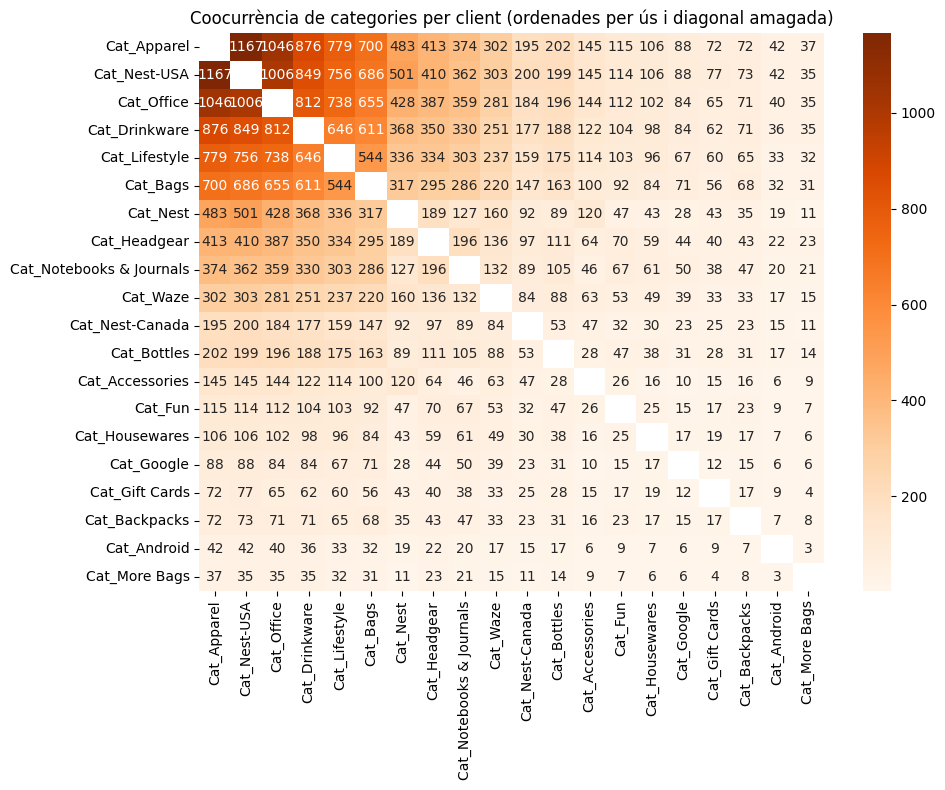

In [3]:
# 1. Ordenem les categories segons el total de compres per categoria
category_order = customer_cat.sum().sort_values(ascending=False).index.tolist()

# 2. Reordenem la matriu de coocurrència segons aquest ordre
co_matrix_visual = category_co_matrix_cust.loc[category_order, category_order].astype(float)

# 3. Amaguem la diagonal
np.fill_diagonal(co_matrix_visual.values, np.nan)

# 4. Visualització
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_visual, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrència de categories per client (ordenades per ús i diagonal amagada)")
plt.tight_layout()
plt.show()


In [4]:
# Comptem quants clients han comprat almenys una vegada cada categoria
clients_per_category = customer_cat.sum()

# Imprimim el resultat
print("Nombre de clients per categoria:")
print(clients_per_category)


Nombre de clients per categoria:
Cat_Accessories              150
Cat_Android                   42
Cat_Apparel                 1323
Cat_Backpacks                 75
Cat_Bags                     728
Cat_Bottles                  203
Cat_Drinkware                919
Cat_Fun                      118
Cat_Gift Cards                77
Cat_Google                    89
Cat_Headgear                 425
Cat_Housewares               107
Cat_Lifestyle                817
Cat_More Bags                 37
Cat_Nest                     516
Cat_Nest-Canada              205
Cat_Nest-USA                1260
Cat_Notebooks & Journals     383
Cat_Office                  1103
Cat_Waze                     309
dtype: int64


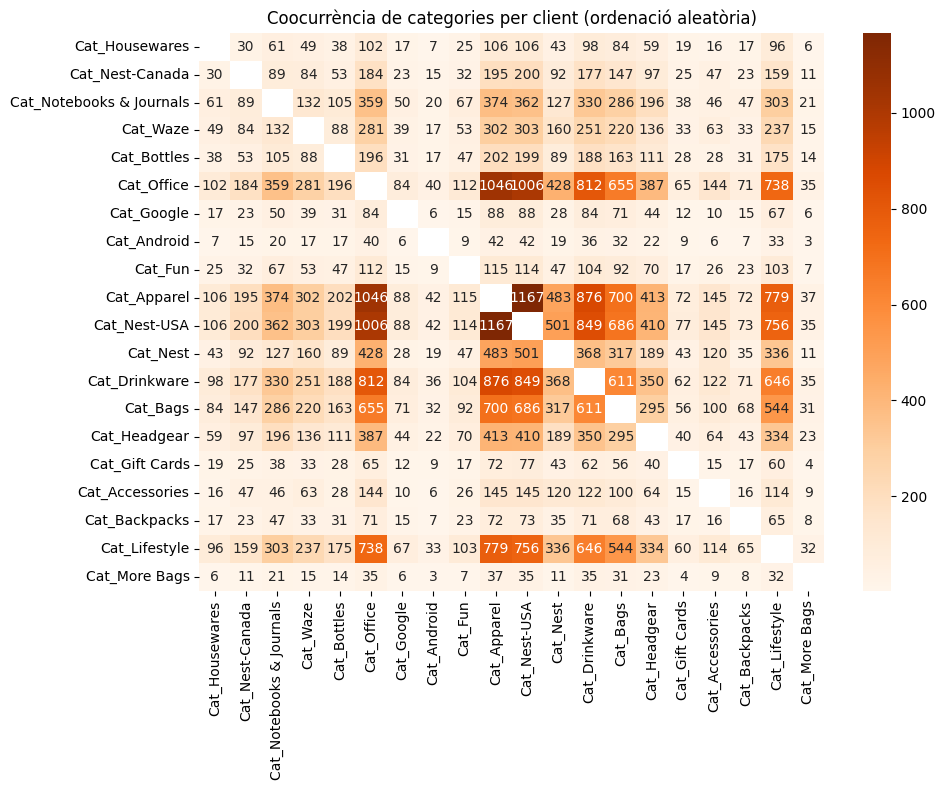

In [5]:
import random

# 1. Llista de categories aleatòriament ordenada
random_order = category_co_matrix_cust.columns.tolist()
random.shuffle(random_order)

# 2. Reordenem la matriu
co_matrix_random = category_co_matrix_cust.loc[random_order, random_order].astype(float)

# 3. Amaguem la diagonal
np.fill_diagonal(co_matrix_random.values, np.nan)

# 4. Visualització
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix_random, annot=True, cmap="Oranges", fmt=".0f", cbar=True)
plt.title("Coocurrència de categories per client (ordenació aleatòria)")
plt.tight_layout()
plt.show()


Busquem ordenar les categories numèricament segons proximitat

Busquem les temporalitats trimestrals de compra de cada categoria de productes i hi assignem un valor

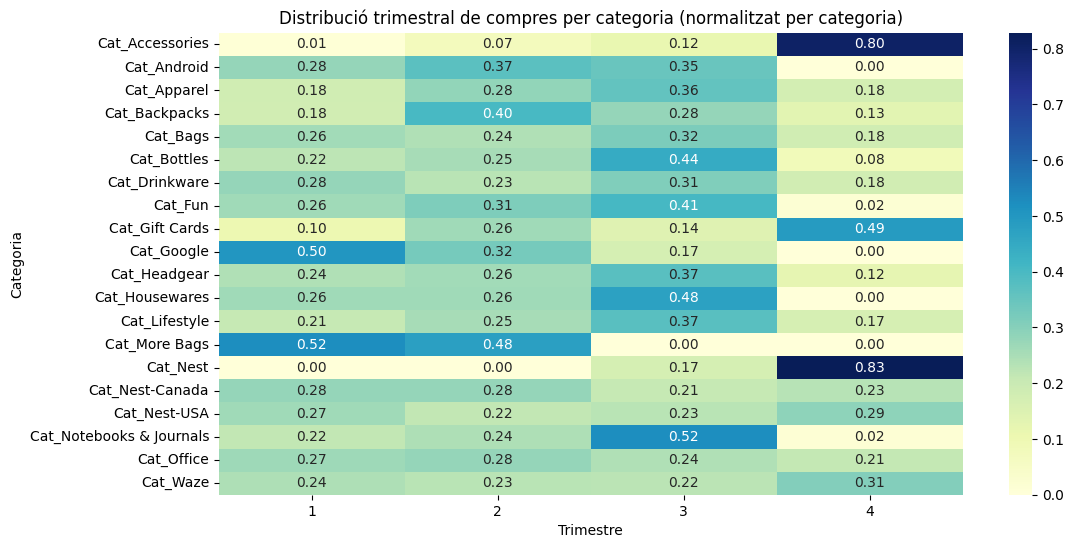

Cat_More Bags               1.478261
Cat_Google                  1.666667
Cat_Android                 2.069767
Cat_Fun                     2.181250
Cat_Housewares              2.213115
Cat_Notebooks & Journals    2.339119
Cat_Backpacks               2.370787
Cat_Headgear                2.380026
Cat_Nest-Canada             2.388013
Cat_Bottles                 2.388060
Cat_Drinkware               2.390181
Cat_Office                  2.399816
Cat_Bags                    2.419766
Cat_Lifestyle               2.495472
Cat_Apparel                 2.531888
Cat_Nest-USA                2.542924
Cat_Waze                    2.590253
Cat_Gift Cards              3.025157
Cat_Accessories             3.713675
Cat_Nest                    3.828480
Name: Seasonality_Index, dtype: float64

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assegurem-nos que 'Month' és numèrica
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')

# Assignem trimestre
df['Quarter'] = df['Month'].apply(lambda x: (int(x)-1)//3 + 1 if pd.notnull(x) else None)

# Seleccionem les columnes de categoria i trimestre
category_cols = [col for col in df.columns if col.startswith('Cat_')]
df_cat_quarter = df[['Quarter'] + category_cols].copy().dropna()

# Agrupem per trimestre i sumem les compres per categoria
category_quarter_matrix = df_cat_quarter.groupby('Quarter')[category_cols].sum().T

# Normalització per files (per categoria)
category_quarter_norm = category_quarter_matrix.div(category_quarter_matrix.sum(axis=1), axis=0)

# Visualització amb escala de proporció
plt.figure(figsize=(12, 6))
sns.heatmap(category_quarter_norm, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Distribució trimestral de compres per categoria (normalitzat per categoria)")
plt.xlabel("Trimestre")
plt.ylabel("Categoria")
plt.show()


# Índex temporal per trimestre
quarter_weights = pd.Series({1: 1, 2: 2, 3: 3, 4: 4})

# Calculem la mitjana ponderada per cada categoria
seasonality_index = category_quarter_norm.dot(quarter_weights)

# Afegim-ho com a nova feature
seasonality_index.name = 'Seasonality_Index'

# Mostrem resultats ordenats
seasonality_index = seasonality_index.sort_values()
seasonality_index


Creem un dataframe on ajuntem les dades de les categories que hem obtingut

In [7]:
# 1. Identifiquem la categoria principal per cada fila
category_cols = [col for col in df.columns if col.startswith('Cat_')]

def get_category(row):
    for col in category_cols:
        if row[col] == 1:
            return col
    return None

# 2. Creem una còpia del dataframe i afegim la categoria principal
df_with_categories = df.copy()
df_with_categories['Product_Category'] = df_with_categories.apply(get_category, axis=1)

# 3. Apliquem el mapatge de valors ordinals obtingut via MDS
df_with_categories['Category_Ordinal_MDS'] = df_with_categories['Product_Category'].map(category_mds_order_map)


NameError: name 'category_mds_order_map' is not defined

Preparem el clustering de categories

In [ ]:
# 1. MDS 1D des de la matriu de coocurrència penalitzada
mds_series = pd.Series(category_coords_1d.flatten(), index=distance_matrix.index, name='MDS_1D')

# 2. Índex d'estacionalitat calculat abans
seasonality_index.name = 'Seasonality_Index'

# 3. Unificació de les dues fonts en un sol DataFrame
df_cat_features = pd.concat([mds_series, seasonality_index], axis=1).dropna()


Apliquem K-means a les categories de productes

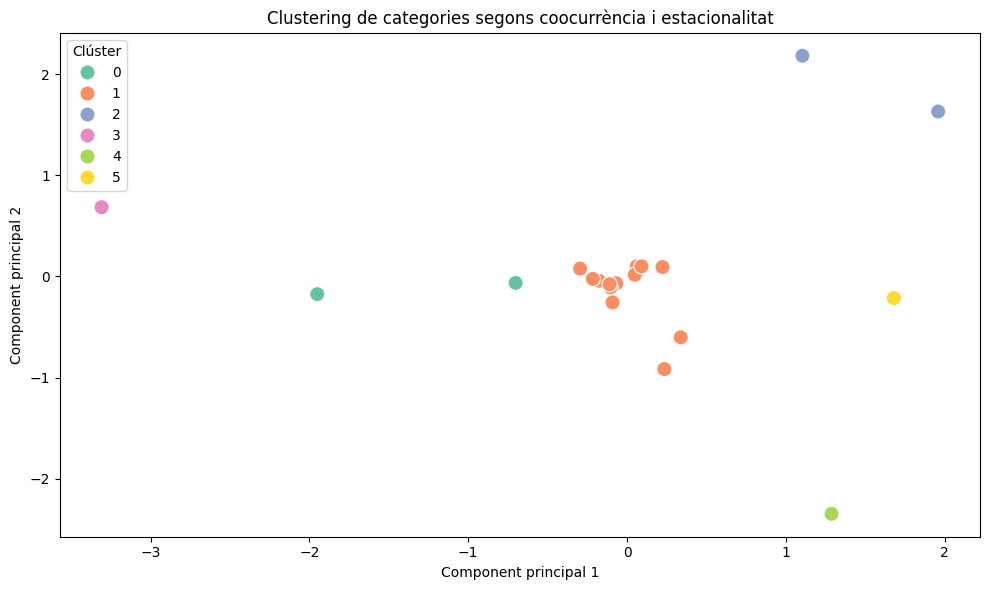

Silhouette Score (K-Means): 0.493
Davies Bouldin Score (K-Means): 0.402


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

df_cat_features.columns = df_cat_features.columns.astype(str)


# Escalem les dades
X = StandardScaler().fit_transform(df_cat_features)

# Reducció de dimensionalitat per visualització
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

# Clustering amb K-Means
kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit_predict(X)

# Construïm el DataFrame per visualitzar
df_plot = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_cat_features.index)
df_plot['Cluster'] = labels

# Visualització
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='Cluster', s=120, palette="Set2")
plt.title("Clustering de categories segons coocurrència i estacionalitat")
plt.xlabel("Component principal 1")
plt.ylabel("Component principal 2")
plt.legend(title="Clúster")
plt.tight_layout()
plt.show()

# Resultats agrupats
df_plot.sort_values(by='Cluster')

sil_score = silhouette_score(X, labels)  # Per K-Means
print(f"Silhouette Score (K-Means): {round(sil_score, 3)}")
db_score = davies_bouldin_score(X, labels)
print(f"Davies Bouldin Score (K-Means): {round(db_score, 3)}")


Spectral Clustering a les categories de productes

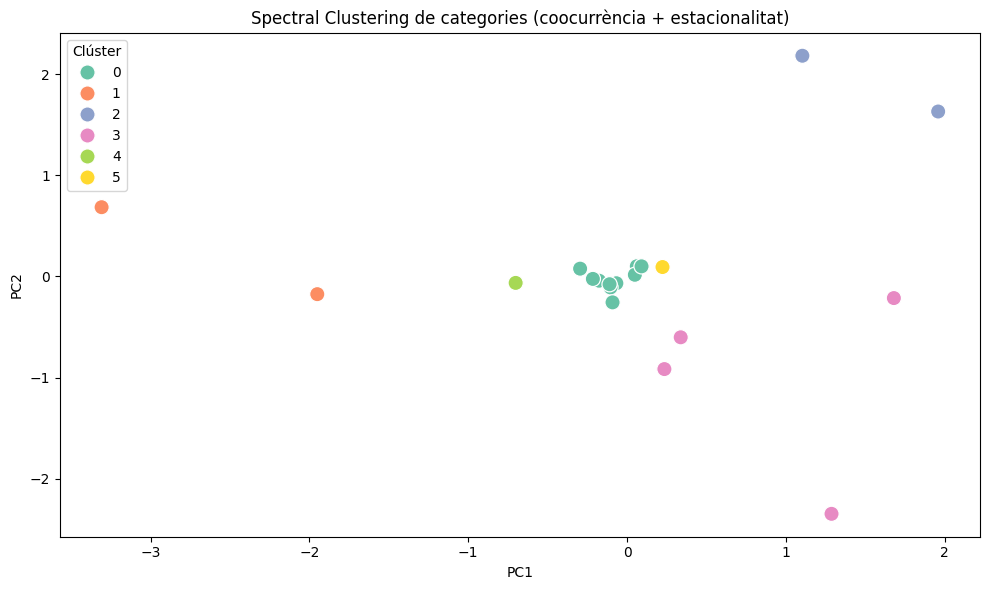

Silhouette Score (Spectral): 0.173
Davies Bouldin Score (Spectral): 0.402


In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Escalem les dades
X = StandardScaler().fit_transform(df_cat_features.drop(columns=['Cluster'], errors='ignore'))

# Spectral Clustering (pots ajustar n_clusters)
spectral = SpectralClustering(n_clusters=6, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42)
spectral_labels = spectral.fit_predict(X)

# Visualització amb PCA
pca = PCA(n_components=2)
coords = pca.fit_transform(X)

df_plot_spectral = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df_cat_features.index)
df_plot_spectral['Cluster'] = spectral_labels

# Gràfic
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot_spectral, x='PC1', y='PC2', hue='Cluster', s=120, palette="Set2")
plt.title("Spectral Clustering de categories (coocurrència + estacionalitat)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Clúster")
plt.tight_layout()
plt.show()

# Llistat de categories agrupades
df_plot_spectral.sort_values(by='Cluster')

sil_score_spectral = silhouette_score(X, spectral_labels)  # Per Spectral Clustering
print(f"Silhouette Score (Spectral): {round(sil_score_spectral, 3)}")
db_score = davies_bouldin_score(X, labels)
print(f"Davies Bouldin Score (Spectral): {round(db_score, 3)}")


Ara afegim els valors dels diferents clusters a les dades per tal de tenir-los guardats

In [ ]:
# Guardem els clústers com a diccionari: categoria → clúster
category_cluster_map_kmeans = df_plot['Cluster'].to_dict()
category_cluster_map_spectral = df_plot_spectral['Cluster'].to_dict()

df_with_categories['Category_Cluster_KMeans'] = df_with_categories['Product_Category'].map(category_cluster_map_kmeans)
df_with_categories['Category_Cluster_Spectral'] = df_with_categories['Product_Category'].map(category_cluster_map_spectral)


Productes agrupats segons clusters


In [ ]:
df['Month'] = pd.to_numeric(df['Month'], errors='coerce')  # Ens assegurem que és numèrica

df['Quarter'] = df['Month'].apply(lambda x: (int(x) - 1) // 3 + 1 if pd.notnull(x) else None)


In [ ]:
# Recalculem les noves variables
num_clients = df.groupby('Product_Description')['CustomerID'].nunique().rename('Num_Clients')
avg_quarter = df.groupby('Product_Description')['Quarter'].mean().rename('Avg_Quarter')

df_products = df_with_categories.groupby('Product_Description').agg({
    'Quantity': 'sum',
    'Avg_Price': 'mean',
    'Category_Ordinal_MDS': 'first',
    'Category_Cluster_KMeans': 'first',
    'Category_Cluster_Spectral': 'first',
    'Product_Category': 'first'
}).join([num_clients, avg_quarter]).dropna()



In [ ]:
df_products.head()

,Quantity,Avg_Price,Category_Ordinal_MDS,Category_Cluster_KMeans,Category_Cluster_Spectral,Product_Category,Num_Clients,Avg_Quarter
Product_Description,,,,,,,,
Dog Frisbee,767.0,1.372708,8,1,0,Cat_Lifestyle,100,2.423611
1 oz Hand Sanitizer,2434.0,1.873566,8,1,0,Cat_Lifestyle,112,2.217054
20 oz Stainless Steel Insulated Tumbler,392.0,22.348053,9,1,0,Cat_Drinkware,97,1.628319
22 oz Android Bottle,1010.0,2.787122,14,1,0,Cat_Bottles,121,2.179856
22 oz YouTube Bottle Infuser,1080.0,4.137674,14,1,0,Cat_Bottles,113,2.612403


Coclustering client-mes

In [ ]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar les dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Conversió i neteja
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "CustomerID"])

# 3. Crear matriu client × mes
client_month_matrix = pd.crosstab(df["CustomerID"], df["Month"])

# 4. Filtrar dades poc significatives
filtered_client_month = client_month_matrix.loc[
    client_month_matrix.gt(0).sum(axis=1) >= 3,
    client_month_matrix.gt(0).sum(axis=0) >= 5
]

# 5. Coclústers amb més grups
n_clusters = 8
model_cm = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cm.fit(filtered_client_month)

# 6. Afegim els coclústers
filtered_client_month["Client_Cluster"] = model_cm.row_labels_
month_clusters_cm = pd.DataFrame({
    "Month": filtered_client_month.columns[:-1],
    "Month_Cluster": model_cm.column_labels_
})

# 7. Exportació
filtered_client_month.reset_index().to_csv("client_month_coclusters.csv", index=False)
month_clusters_cm.to_csv("month_coclusters_client_view.csv", index=False)

# 8. Visualització millorada
# Reordenem
reordered_matrix = filtered_client_month.drop("Client_Cluster", axis=1).iloc[
    model_cm.row_labels_.argsort(),
    model_cm.column_labels_.argsort()
]

# Divisions per coclústers (línies de separació)
row_ticks = np.cumsum(np.bincount(model_cm.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cm.column_labels_))[:-1]

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)
plt.title("Matriu client × mes coclusteritzada (amb separació de grups)")
plt.xlabel("Mes")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


Coclustering producte-mes

In [ ]:
import pandas as pd
from sklearn.cluster import SpectralCoclustering
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Carregar les dades
df = pd.read_csv("../data/df_preparat.csv")

# 2. Conversió i neteja
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df = df.dropna(subset=["Month", "Product_Description"])

# 3. Crear matriu client × mes
client_month_matrix = pd.crosstab(df["Product_Description"], df["Month"])

# 4. Filtrar dades poc significatives
filtered_client_month = client_month_matrix.loc[
    client_month_matrix.gt(0).sum(axis=1) >= 3,
    client_month_matrix.gt(0).sum(axis=0) >= 5
]

# 5. Coclústers amb més grups
n_clusters = 8
model_cm = SpectralCoclustering(n_clusters=n_clusters, random_state=0)
model_cm.fit(filtered_client_month)

# 6. Afegim els coclústers
filtered_client_month["Product_Cluster"] = model_cm.row_labels_
month_clusters_cm = pd.DataFrame({
    "Month": filtered_client_month.columns[:-1],
    "Month_Cluster": model_cm.column_labels_
})

# 7. Exportació
filtered_client_month.reset_index().to_csv("product_month_coclusters.csv", index=False)
month_clusters_cm.to_csv("month_coclusters_product_view.csv", index=False)

# 8. Visualització millorada
# Reordenem
reordered_matrix = filtered_client_month.drop("Product_Cluster", axis=1).iloc[
    model_cm.row_labels_.argsort(),
    model_cm.column_labels_.argsort()
]

# Divisions per coclústers (línies de separació)
row_ticks = np.cumsum(np.bincount(model_cm.row_labels_))[:-1]
col_ticks = np.cumsum(np.bincount(model_cm.column_labels_))[:-1]

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(reordered_matrix, cmap="Blues", cbar=True, xticklabels=True, yticklabels=False)
for r in row_ticks:
    ax.axhline(r, color='black', lw=1)
for c in col_ticks:
    ax.axvline(c, color='black', lw=1)
plt.title("Matriu producte × mes coclusteritzada (amb separació de grups)")
plt.xlabel("Mes")
plt.ylabel("Producte")
plt.tight_layout()
plt.show()
